In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor #Import of the function variance_inflation_factor
from IPython import get_ipython
from IPython.display import display
from pyspark.sql import SparkSession
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBClassifier
import shap
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Create a SparkSession
spark = SparkSession.builder.appName("USADataFilter").getOrCreate()

# Load data into a PySpark DataFrame
df_spark = spark.read.csv("/datalab/thyroid_cancer_risk_data.csv", header=True, inferSchema=True)

# USA filter
df_spark = df_spark.filter(df_spark["Country"] == "USA")

# first few rows
df_spark.show(5)


+----------+---+------+-------+---------+--------------+------------------+-----------------+-------+-------+--------+---------+--------+--------+-----------+-------------------+---------+
|Patient_ID|Age|Gender|Country|Ethnicity|Family_History|Radiation_Exposure|Iodine_Deficiency|Smoking|Obesity|Diabetes|TSH_Level|T3_Level|T4_Level|Nodule_Size|Thyroid_Cancer_Risk|Diagnosis|
+----------+---+------+-------+---------+--------------+------------------+-----------------+-------+-------+--------+---------+--------+--------+-----------+-------------------+---------+
|        19| 47|Female|    USA|Caucasian|            No|                No|               No|     No|     No|     Yes|     6.43|    3.39|    5.66|       1.63|             Medium|   Benign|
|        29| 61|Female|    USA| Hispanic|            No|                No|               No|    Yes|     No|      No|     4.07|    2.27|   10.98|       4.26|                Low|   Benign|
|        53| 50|Female|    USA| Hispanic|           Yes

In [3]:
# Convert to Pandas for EDA
df_pandas = df_spark.toPandas()

# Only USA data
df_usa = df_pandas[df_pandas["Country"] == "USA"]

# First few rows
print(df_usa.head())
df_usa.info()

   Patient_ID  Age  Gender Country  Ethnicity Family_History  \
0          19   47  Female     USA  Caucasian             No   
1          29   61  Female     USA   Hispanic             No   
2          53   50  Female     USA   Hispanic            Yes   
3          54   64  Female     USA   Hispanic             No   
4          57   20    Male     USA    African             No   

  Radiation_Exposure Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  \
0                 No                No      No      No      Yes       6.43   
1                 No                No     Yes      No       No       4.07   
2                 No                No      No      No       No       8.88   
3                 No                No      No      No      Yes       2.52   
4                 No               Yes     Yes      No       No       5.00   

   T3_Level  T4_Level  Nodule_Size Thyroid_Cancer_Risk  Diagnosis  
0      3.39      5.66         1.63              Medium     Benign  
1      2.2

In [4]:
# Defining numerical and categorical columns
numerical_cols = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
categorical_cols = ['Gender', 'Ethnicity', 'Family_History', 'Radiation_Exposure',
                    'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Thyroid_Cancer_Risk']

# Encode categorical features
df_encoded = df_usa.copy()
for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Encode 'Diagnosis'
df_encoded['Diagnosis'] = LabelEncoder().fit_transform(df_encoded['Diagnosis'])

# Standardize numerical features
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Apply PCA to numerical columns
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_encoded[numerical_cols])
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])

# Combine PCA-transformed features with categorical features and target variable
df_final = pd.concat([df_pca, df_encoded[categorical_cols], df_encoded['Diagnosis']], axis=1)

# Add 'Age' back into df_final
df_final['Age'] = df_encoded['Age']
print(df_final.head())

        PC1       PC2       PC3  Gender  Ethnicity  Family_History  \
0 -0.784292 -0.465650  0.543175       0          2               0   
1 -0.009009  0.013418  0.744165       0          3               0   
2  1.990897 -0.393389 -0.736285       0          3               1   
3  0.086509  0.731422 -0.356050       0          3               0   
4 -0.591937  0.832007 -1.377287       1          0               0   

   Radiation_Exposure  Iodine_Deficiency  Smoking  Obesity  Diabetes  \
0                   0                  0        0        0         1   
1                   0                  0        1        0         0   
2                   0                  0        0        0         0   
3                   0                  0        0        0         1   
4                   0                  1        1        0         0   

   Thyroid_Cancer_Risk  Diagnosis       Age  
0                    2          0 -0.232503  
1                    1          0  0.421255  
2       

<Figure size 1500x1000 with 0 Axes>

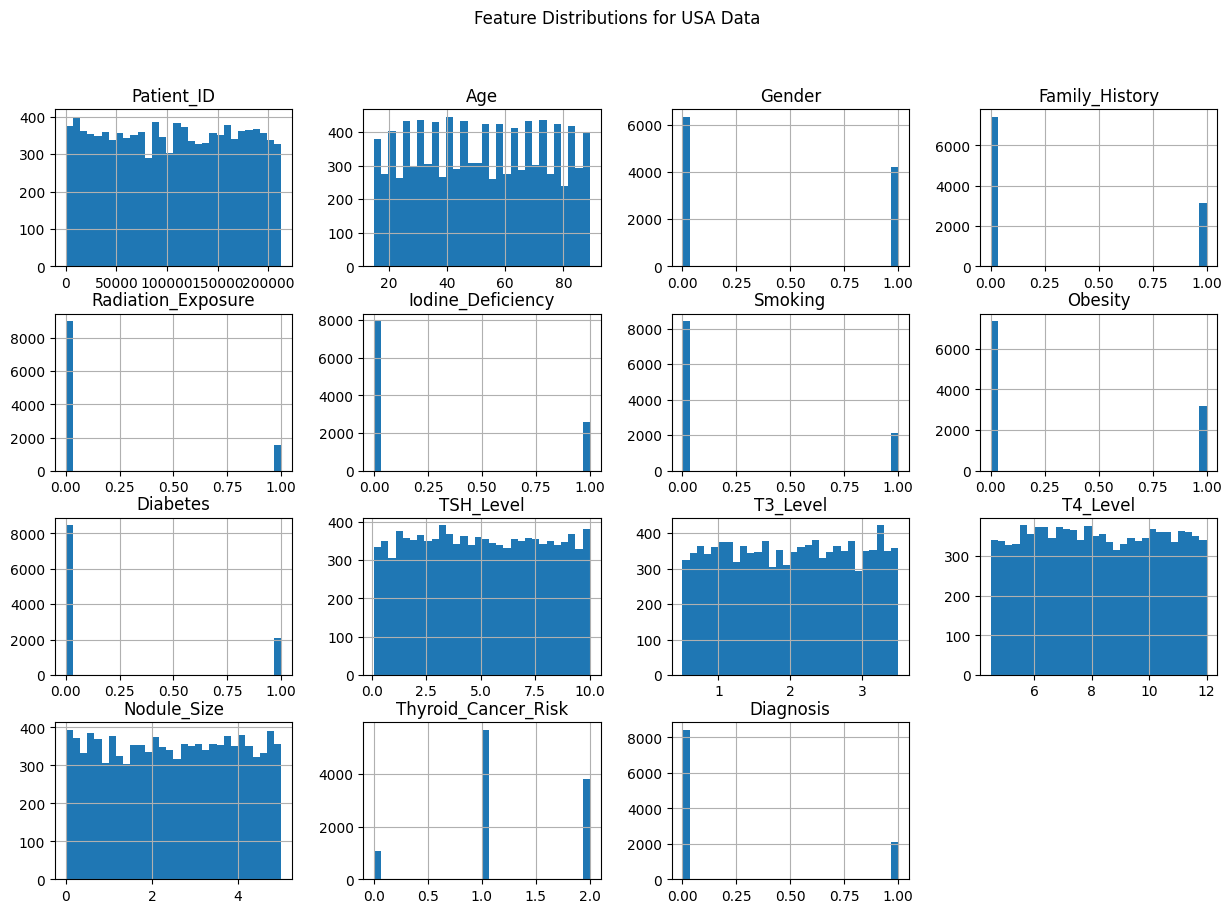

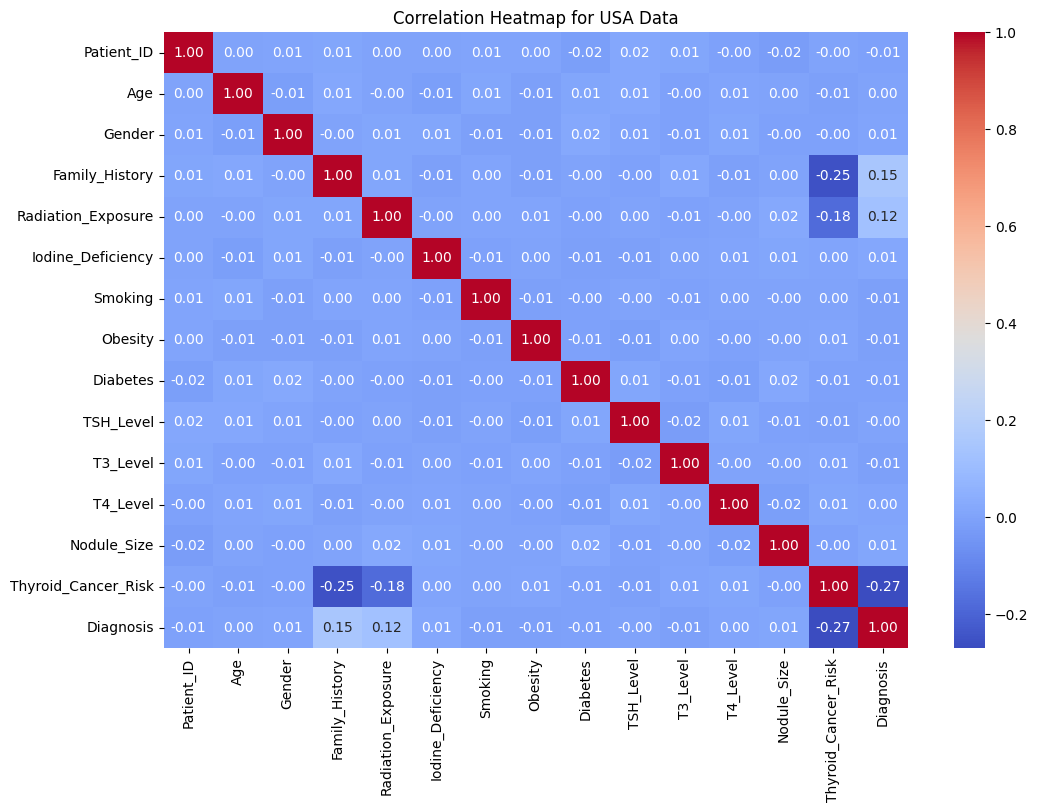

In [5]:
# Convert categorical columns to numerical for analysis
categorical_columns = ["Gender", "Family_History", "Radiation_Exposure", "Iodine_Deficiency",
                        "Smoking", "Obesity", "Diabetes", "Thyroid_Cancer_Risk", "Diagnosis"]

for col in categorical_columns:
    df_usa[col] = df_usa[col].astype('category').cat.codes

# Summary Statistics
summary_stats = df_usa.describe()

# Correlation matriix
numerical_df_usa = df_usa.select_dtypes(include=np.number)
correlation_matrix = numerical_df_usa.corr()

# Plot Feature Distributions
plt.figure(figsize=(15, 10))
df_usa.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions for USA Data")
plt.show()

# Heatmap for Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap for USA Data")
plt.show()

Logistic Regression Accuracy: 0.6482

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75      1688
           1       0.30      0.56      0.39       424

    accuracy                           0.65      2112
   macro avg       0.58      0.61      0.57      2112
weighted avg       0.75      0.65      0.68      2112

Random Forest Accuracy: 0.7831

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87      1688
           1       0.45      0.40      0.42       424

    accuracy                           0.78      2112
   macro avg       0.65      0.64      0.65      2112
weighted avg       0.77      0.78      0.78      2112

Support Vector Machine Accuracy: 0.6832

Support Vector Machine Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.73      0.79      16

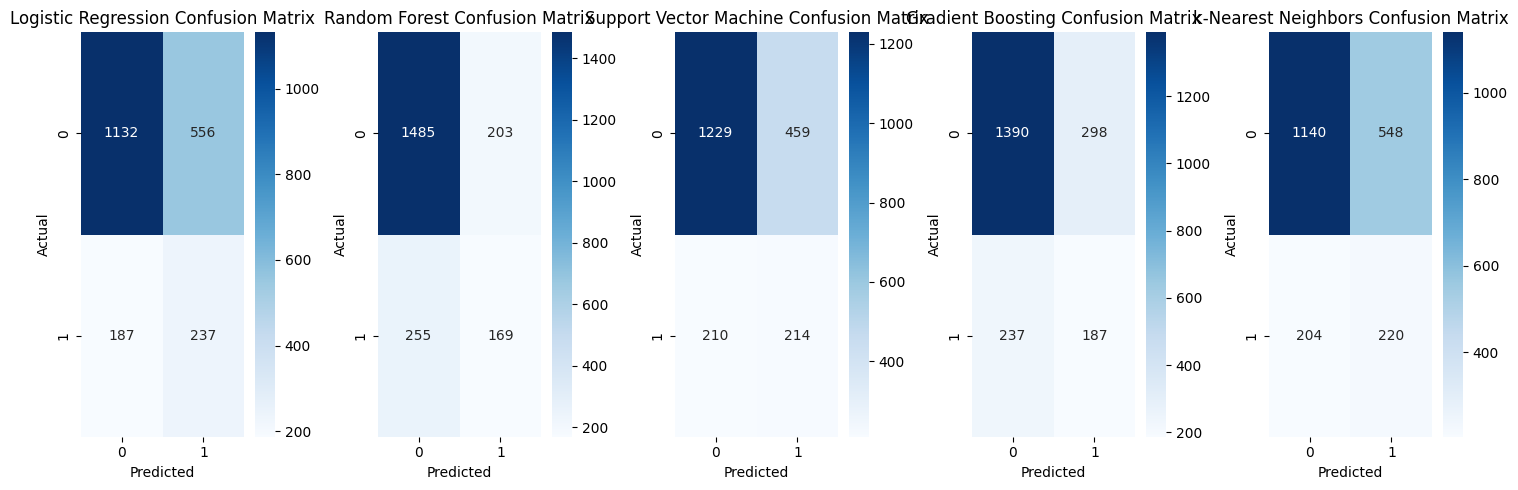

In [6]:
# Remove rows with missing target values
df_final.dropna(inplace=True)

# Split dataset into training and testing sets
X = df_final.drop(columns=['Diagnosis'])
y = df_final['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Define ML models with class weighting
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, class_weight="balanced"),
    "Support Vector Machine": SVC(kernel='linear', probability=True, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))

# Confusion Matrices Visualization
fig, axes = plt.subplots(1, len(models), figsize=(15, 5))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()




Tuning Logistic Regression...
Logistic Regression Accuracy After Tuning: 0.6501

Logistic Regression Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000}


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75      1688
           1       0.30      0.56      0.39       424

    accuracy                           0.65      2112
   macro avg       0.58      0.62      0.57      2112
weighted avg       0.75      0.65      0.68      2112

Tuning Random Forest...
Random Forest Accuracy After Tuning: 0.7462

Random Forest Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1688
           1       0.39      0.45      0.42       424

    accuracy                           0.75      2112
   macro avg       0.62    

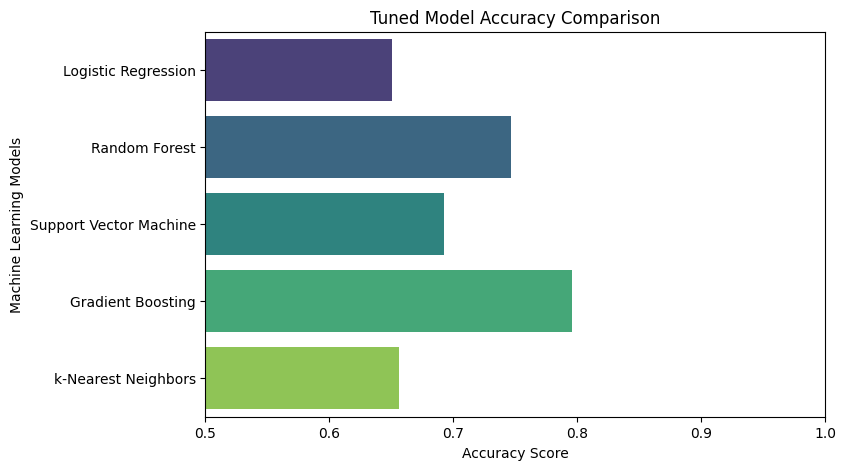

In [7]:
# Hyperparameter tuning grid
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10],
        "class_weight": ["balanced"]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "Support Vector Machine": {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "class_weight": ["balanced"]
    },
    "k-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "max_iter": [1000],
        "C": [0.1, 1, 10],
        "class_weight": ["balanced"]
    }
}

# ML models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "k-Nearest Neighbors": KNeighborsClassifier()
}

# Perform hyperparameter tuning and evaluation
tuned_results = {}
best_params = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Best model after tuning
    best_model = grid_search.best_estimator_
    best_params[name] = grid_search.best_params_

    # Evaluate model
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    tuned_results[name] = accuracy

    print(f"{name} Accuracy After Tuning: {accuracy:.4f}")
    print(f"\n{name} Best Parameters: {grid_search.best_params_}\n")
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))

# Converting to DataFrame
results_df = pd.DataFrame(list(tuned_results.items()), columns=["Model", "Tuned Accuracy"])

# Results table
print("\nTuned Model Accuracy Comparison:")
print(results_df)

# Plot the accuracy of tuned models
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Tuned Accuracy", y="Model", hue="Model", dodge=False, legend=False, palette="viridis")
plt.xlim(0.5, 1.0)
plt.title("Tuned Model Accuracy Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Models")
plt.show()



<Figure size 1000x600 with 0 Axes>

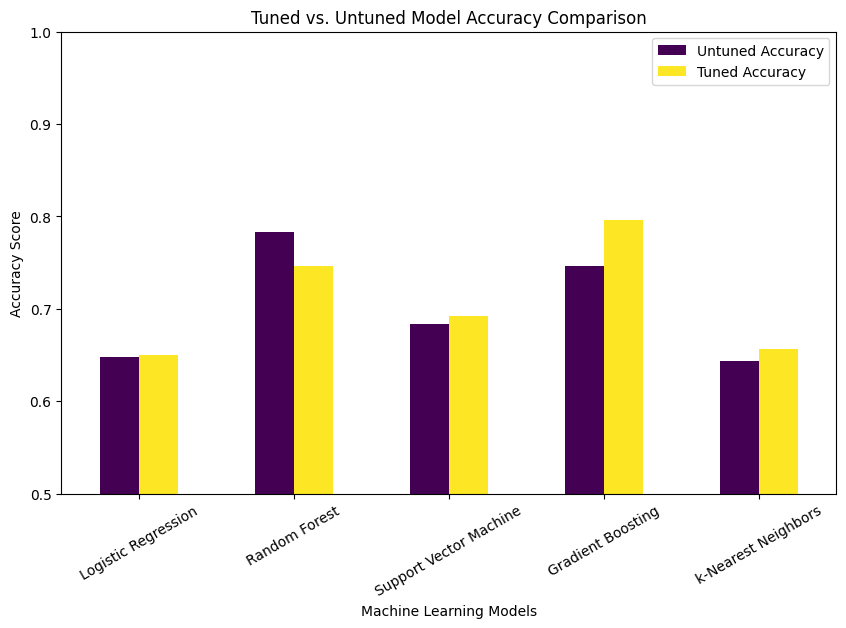

In [8]:
# Store untuned model accuracies from previous results (before tuning)
untuned_results = {
    "Logistic Regression": 0.6482,
    "Random Forest": 0.7831,
    "Support Vector Machine": 0.6832,
    "Gradient Boosting": 0.7467,
    "k-Nearest Neighbors": 0.6439
}

# Convert results to DataFrame for visualization
comparison_df = pd.DataFrame({
    "Model": tuned_results.keys(),
    "Untuned Accuracy": [untuned_results[m] for m in tuned_results.keys()],
    "Tuned Accuracy": list(tuned_results.values())
})

# Plot tuned vs. untuned model accuracies
plt.figure(figsize=(10, 6))
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.ylim(0.5, 1.0)
plt.title("Tuned vs. Untuned Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=30)
plt.legend(["Untuned Accuracy", "Tuned Accuracy"])
plt.show()


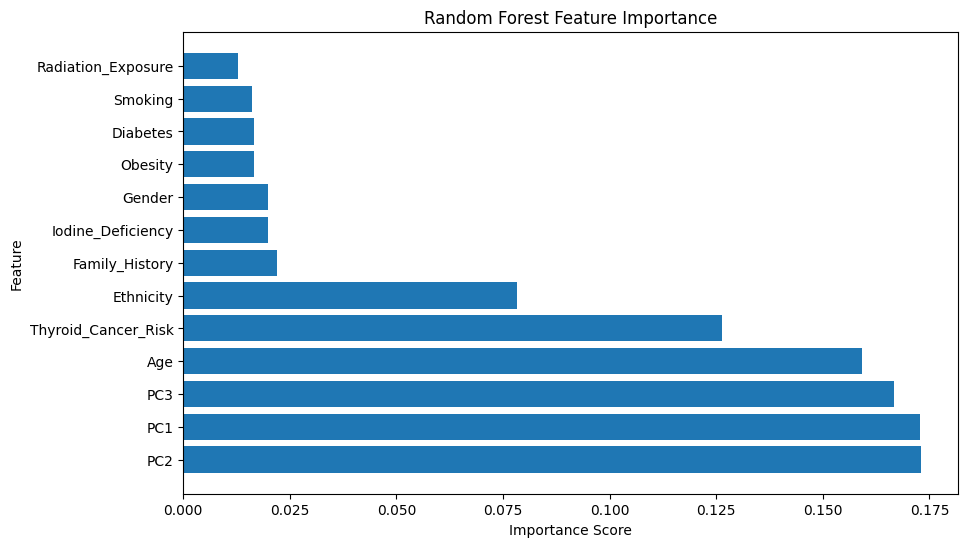

PCA Loadings (Contribution of each feature to PC1-3):
                  PC1       PC2       PC3
Age          0.367483  0.240873  0.816421
TSH_Level    0.610443  0.265416 -0.058988
T3_Level    -0.408226 -0.471067  0.554684
T4_Level     0.458267 -0.493329  0.027005
Nodule_Size -0.340084  0.637383  0.146879


In [9]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded[numerical_cols])

# Fit PCA
pca = PCA(n_components=3)
pca.fit(X_scaled)

# Display PCA loadings
pca_loadings = pd.DataFrame(pca.components_.T,
                            columns=['PC1', 'PC2', 'PC3'],
                            index=numerical_cols)

print("PCA Loadings (Contribution of each feature to PC1-3):")
print(pca_loadings)



In [10]:
# Select refined features
selected_features = ['PC1', 'PC2', 'PC3', 'Age',
                     'Thyroid_Cancer_Risk', 'Ethnicity']

X_train_selected = X_train[selected_features]
# Train the improved RM model
rf_model_refined = RandomForestClassifier(n_estimators=200,
                                          max_depth=10,
                                          class_weight='balanced',
                                          random_state=42)
rf_model_refined.fit(X_train[selected_features], y_train)

# Evaluate
y_pred = rf_model_refined.predict(X_test[selected_features])
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1688
           1       0.53      0.37      0.44       424

    accuracy                           0.81      2112
   macro avg       0.69      0.64      0.66      2112
weighted avg       0.79      0.81      0.79      2112



In [11]:
# Train the improved XGBoost model
xgb_model = XGBClassifier(n_estimators=200,
                          max_depth=6,
                          learning_rate=0.1,
                          scale_pos_weight=4,
                          random_state=42)
xgb_model.fit(X_train[selected_features], y_train)

# Evaluate
y_pred = xgb_model.predict(X_test[selected_features])
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.35      0.49      1688
           1       0.23      0.79      0.36       424

    accuracy                           0.43      2112
   macro avg       0.55      0.57      0.43      2112
weighted avg       0.74      0.43      0.47      2112



In [12]:
from sklearn.metrics import precision_recall_curve, classification_report

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test[selected_features])[:, 1]

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Optimal threshold
optimal_idx = np.argmax(precision + recall)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold Identified: {optimal_threshold:.2f}")

# Predict using the tuned threshold
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)

# Evaluate performance
print("XGBoost with Tuned Threshold:")
print(classification_report(y_test, y_pred_tuned))


Optimal Threshold Identified: 0.02
XGBoost with Tuned Threshold:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01      1688
           1       0.20      1.00      0.34       424

    accuracy                           0.20      2112
   macro avg       0.60      0.50      0.17      2112
weighted avg       0.84      0.20      0.07      2112



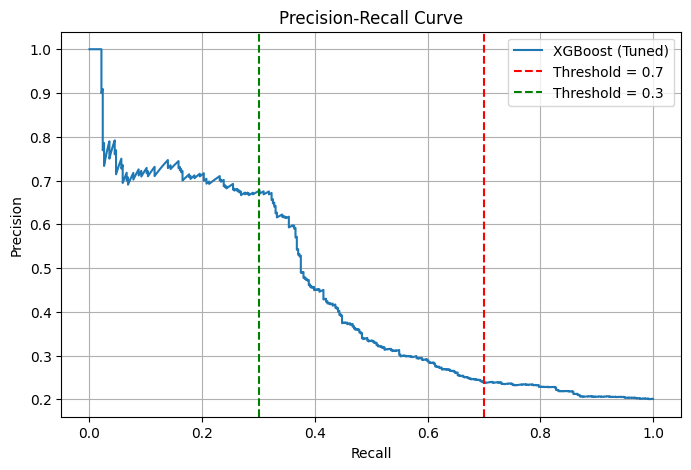

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label='XGBoost (Tuned)')
plt.axvline(x=0.7, color='red', linestyle='--', label='Threshold = 0.7')
plt.axvline(x=0.3, color='green', linestyle='--', label='Threshold = 0.3')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# Untuned model performance data
untuned_data = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "k-NN"
    ],
    "Benign Precision": [0.86, 0.85, 0.85, 0.85, 0.85],
    "Benign Recall": [0.67, 0.88, 0.73, 0.82, 0.68],
    "Malignant Precision": [0.30, 0.45, 0.32, 0.39, 0.29],
    "Malignant Recall": [0.56, 0.40, 0.50, 0.44, 0.52],
    "Accuracy": [0.6482, 0.7831, 0.6832, 0.7467, 0.6439]
}

# Convert to DataFrame
untuned_df = pd.DataFrame(untuned_data)



<Figure size 1200x600 with 0 Axes>

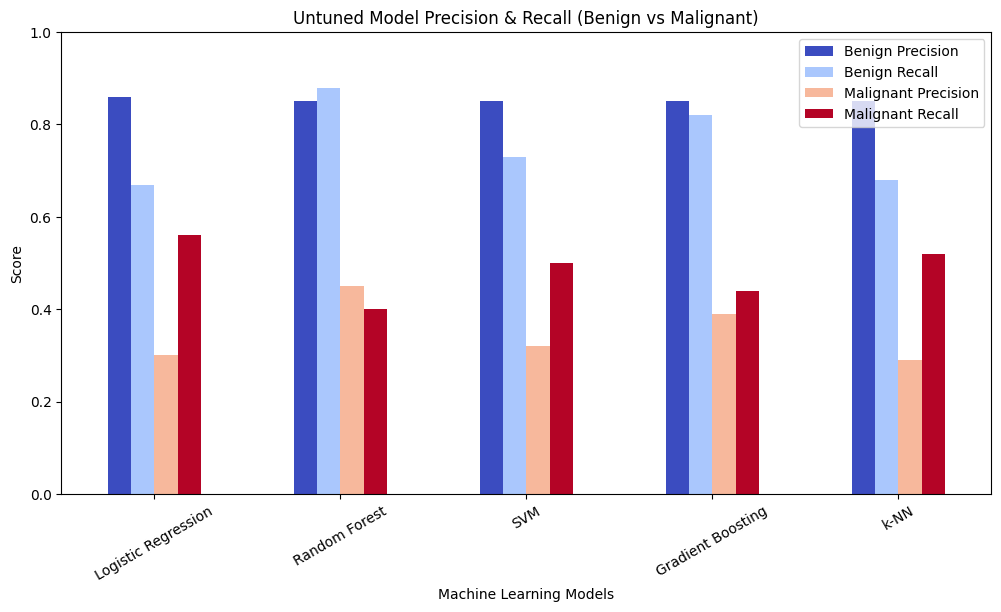

In [15]:
plt.figure(figsize=(12, 6))
untuned_df.set_index("Model")[[
    "Benign Precision", "Benign Recall",
    "Malignant Precision", "Malignant Recall"
]].plot(kind='bar', colormap='coolwarm', figsize=(12, 6))

plt.ylim(0, 1)
plt.title("Untuned Model Precision & Recall (Benign vs Malignant)")
plt.ylabel("Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=30)
plt.legend(["Benign Precision", "Benign Recall", "Malignant Precision", "Malignant Recall"])
plt.show()


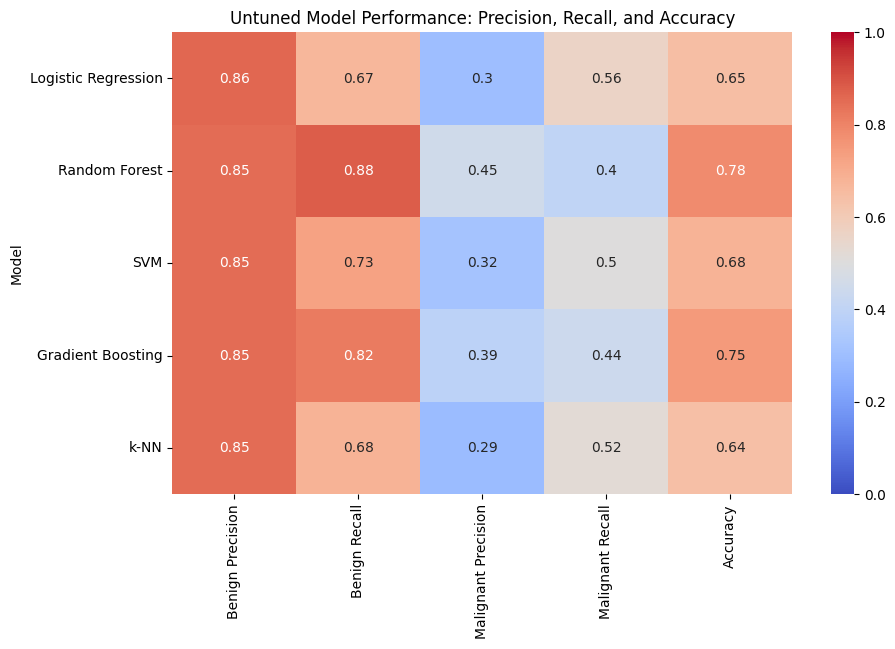

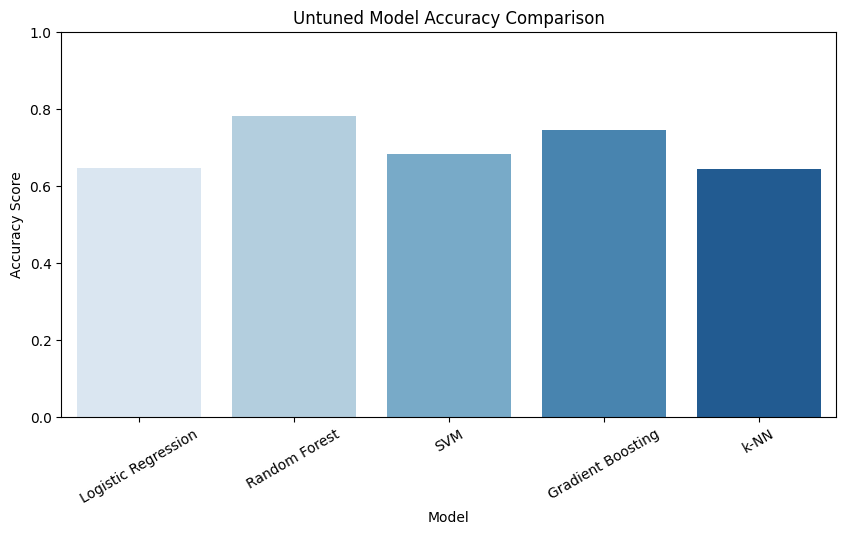

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(untuned_df.set_index("Model"), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Untuned Model Performance: Precision, Recall, and Accuracy")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=untuned_df, hue='Model', palette='Blues', legend=False)

plt.title("Untuned Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()


In [17]:
# Performance data for each class (Benign = 0, Malignant = 1)
performance_data = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "k-NN"
    ],
    "Benign Precision": [0.86, 0.85, 0.86, 0.85, 0.85],
    "Benign Recall": [0.67, 0.82, 0.74, 0.91, 0.69],
    "Malignant Precision": [0.30, 0.39, 0.33, 0.49, 0.30],
    "Malignant Recall": [0.56, 0.44, 0.52, 0.37, 0.52],
    "Accuracy": [0.6501, 0.7476, 0.6922, 0.7973, 0.6562]
}

# Convert to DataFrame
performance_df = pd.DataFrame(performance_data)


<Figure size 1200x600 with 0 Axes>

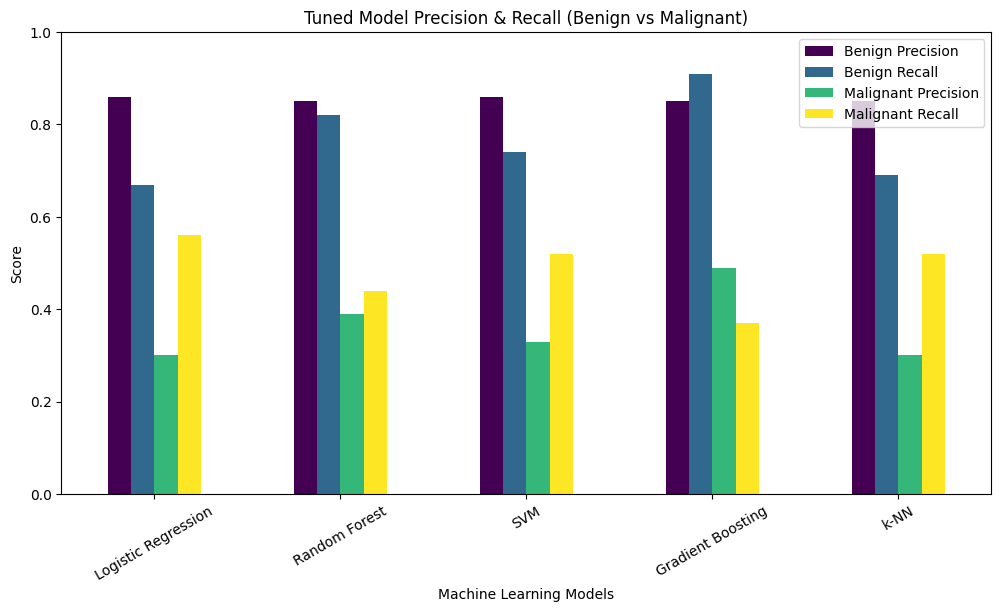

In [18]:
plt.figure(figsize=(12, 6))

# Plot Precision and Recall for each class
performance_df.set_index("Model")[["Benign Precision", "Benign Recall",
                                   "Malignant Precision", "Malignant Recall"]].plot(
    kind='bar', colormap='viridis', figsize=(12, 6))

plt.ylim(0, 1)
plt.title("Tuned Model Precision & Recall (Benign vs Malignant)")
plt.ylabel("Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=30)
plt.legend(["Benign Precision", "Benign Recall", "Malignant Precision", "Malignant Recall"])
plt.show()


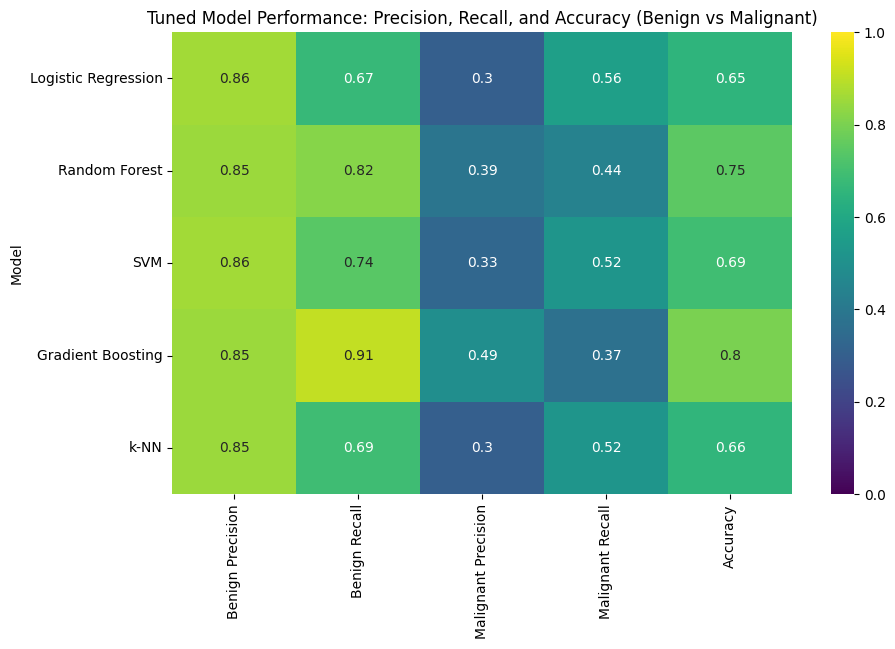

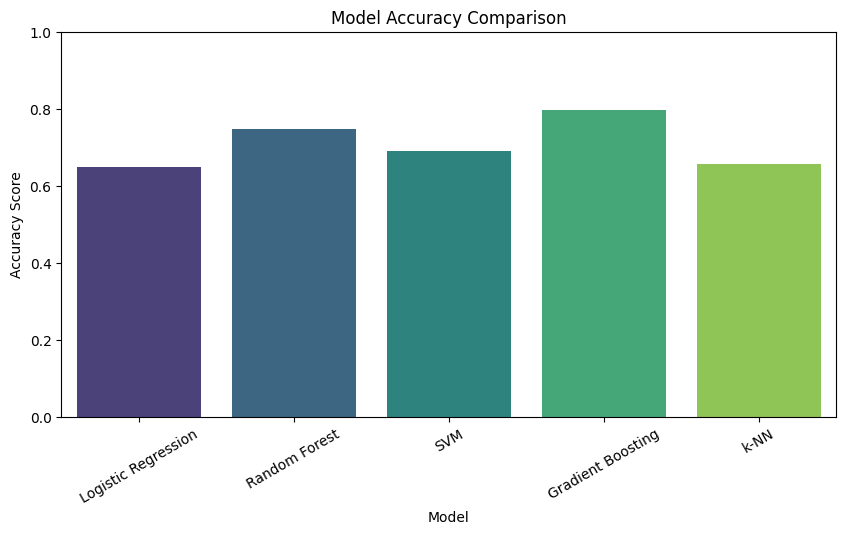

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(performance_df.set_index("Model"), annot=True, cmap='viridis', vmin=0, vmax=1)
plt.title("Tuned Model Performance: Precision, Recall, and Accuracy (Benign vs Malignant)")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=performance_df, hue='Model', palette='viridis', legend=False)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()



In [20]:
# Add a unique index for reference
X_train = X_train.reset_index(drop=True)
X_train['Row_ID'] = X_train.index

X_test = X_test.reset_index(drop=True)
X_test['Row_ID'] = X_test.index

df_encoded = df_encoded.reset_index(drop=True)
df_encoded['Row_ID'] = df_encoded.index

# ... (rest of your code)

# Restore 'Age' column
X_train['Age'] = df_encoded.loc[X_train['Row_ID'], 'Age']
X_test['Age'] = df_encoded.loc[X_test['Row_ID'], 'Age']

# Merge on 'Row_ID' to align rows
X_train = X_train.merge(df_encoded[['Row_ID', 'Gender', 'Age']], on=['Row_ID'])
X_test = X_test.merge(df_encoded[['Row_ID', 'Gender', 'Age']], on=['Row_ID'])

X_train['Age_Obesity_Interaction'] = X_train['Age'] * X_train['Obesity']
X_test['Age_Obesity_Interaction'] = X_test['Age'] * X_test['Obesity']

X_train['Nodule_Radiation_Interaction'] = X_train['Nodule_Size'] * X_train['Radiation_Exposure']
X_test['Nodule_Radiation_Interaction'] = X_test['Nodule_Size'] * X_test['Radiation_Exposure']

combined_features = selected_features + [
    'Iodine_Family_Interaction',
    'Age_Obesity_Interaction',
    'Nodule_Radiation_Interaction'
]

# Train the improved Random Forest model
rf_model_interaction = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model_interaction.fit(X_train[combined_features], y_train)

# Evaluate
y_pred = rf_model_interaction.predict(X_test[combined_features])
print("Random Forest with New Interaction Terms:")
print(classification_report(y_test, y_pred))


KeyError: '[10558, 10559, 10560, 10561, 10562, 10563, 10564, 10565, 10566, 10567, 10568, 10569, 10570, 10571, 10572, 10573, 10574, 10575, 10576, 10577, 10578, 10579, 10580, 10581, 10582, 10583, 10584, 10585, 10586, 10587, 10588, 10589, 10590, 10591, 10592, 10593, 10594, 10595, 10596, 10597, 10598, 10599, 10600, 10601, 10602, 10603, 10604, 10605, 10606, 10607, 10608, 10609, 10610, 10611, 10612, 10613, 10614, 10615, 10616, 10617, 10618, 10619, 10620, 10621, 10622, 10623, 10624, 10625, 10626, 10627, 10628, 10629, 10630, 10631, 10632, 10633, 10634, 10635, 10636, 10637, 10638, 10639, 10640, 10641, 10642, 10643, 10644, 10645, 10646, 10647, 10648, 10649, 10650, 10651, 10652, 10653, 10654, 10655, 10656, 10657, 10658, 10659, 10660, 10661, 10662, 10663, 10664, 10665, 10666, 10667, 10668, 10669, 10670, 10671, 10672, 10673, 10674, 10675, 10676, 10677, 10678, 10679, 10680, 10681, 10682, 10683, 10684, 10685, 10686, 10687, 10688, 10689, 10690, 10691, 10692, 10693, 10694, 10695, 10696, 10697, 10698, 1

In [ ]:
from logging import info
print("df_encoded Columns:", df_encoded.columns.tolist())
info("df_encoded Columns:", df_encoded.columns.tolist())
# Strip spaces from column names
df_encoded.columns = df_encoded.columns.str.strip()
print("df_encoded Index Sample:", df_encoded.index[:5])
print("X_train Index Sample:", X_train.index[:5])
print(X_train)


# Reset index for alignment
df_encoded_reset = df_encoded.reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

# Restore 'Age' column after alignment
X_train['Age'] = df_encoded_reset.loc[X_train_reset.index, 'Age']
X_test['Age'] = df_encoded_reset.loc[X_test_reset.index, 'Age']



# Create new interaction terms
X_train_reset_index = X_train.reset_index(drop=True)
X_test_reset_index = X_test.reset_index(drop=True)

X_train['Age_Obesity_Interaction'] = X_train['Age'] * X_train['Obesity']
X_test['Age_Obesity_Interaction'] = X_test['Age'] * X_test['Obesity']

X_train['Nodule_Radiation_Interaction'] = X_train['Nodule_Size'] * X_train['Radiation_Exposure']
X_test['Nodule_Radiation_Interaction'] = X_test['Nodule_Size'] * X_test['Radiation_Exposure']

# Add features to model
combined_features = selected_features + [
    'Iodine_Family_Interaction',
    'Age_Obesity_Interaction',
    'Nodule_Radiation_Interaction'
]

# Train an improved Random Forest or XGBoost model
rf_model_interaction = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf_model_interaction.fit(X_train[combined_features], y_train)

# Evaluate
y_pred = rf_model_interaction.predict(X_test[combined_features])
print("Random Forest with New Interaction Terms:")
print(classification_report(y_test, y_pred))
